**Proyecto Final de Diplomado en Machine Learning y Deep Learning Aplicado**

Nombre: Predictor de Compras de Materiales

Datos: Información de Compras Publicas

Etapas del Proceso

1.   Limpieza de los datos recuperados
2.   Verificación de la estructura de los datos
3.   Filtrar por informacion útil
4.   Construcción de Modelo de Regresión






Etapa del modelado ML

1. Analisis Exploratorio
2. Empleo de estategia de Modelo de Regresion
3. Evaluacion de rendimiento
4. Proximas etapas

In [2]:
try:
  from google.colab import drive
  drive.mount('/content/drive/')
  DATA_DIR='/content/drive/MyDrive/Diplomado/Proyecto_Final/contratos'
except ModuleNotFoundError:
  DATA_DIR='.'

print('Entorno OK!')

Mounted at /content/drive/
Entorno OK!


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

YEAR_LEN = 4

Luego de recuperado los archivos, deben obtenerse la relaciones entre si para unificar los procesos.
Existe una relacion entre si teniendo la primera columna relacionada entre los archivos.
Tambien existen referencias dentro de cada archivo a considerar para poder obtener los valores necesarios para el caso de estudio.
Cargar los registros y limpiar uno por uno para generar el dataset de entrenamiento.

In [ ]:
# Ejecutar esta celda primero: carga las tablas
for ruta_actual, subdirectorios, archivos in os.walk(DATA_DIR):
  tiene_archivos = any(archivo.endswith('.csv') for archivo in archivos)

  if tiene_archivos:
    # Actualizamos la variable con la última carpeta encontrada
    print(f'Carpeta actual: {ruta_actual}')

    year = ruta_actual[-YEAR_LEN:]
    #print(year)
    for archivo in archivos:
        print(f' - Archivo: {archivo}')

    # leemos los archivos
    contrato = pd.read_csv(ruta_actual+"/parties.csv")
    items = pd.read_csv(ruta_actual+"/awa_items.csv")
    detalles_adj = pd.read_csv(ruta_actual+"/awards.csv")
    print("Adjudicacion (partes):", len(contrato))
    print("Adjudicacion (detalles):", len(detalles_adj))
    print("Items de contratos:", len(items))

    name_filtered_generic = 'data_merged_' + year + '.csv'

    #filtramos los datos importantes por un criterio
    criterio1 = contrato['compiledRelease/parties/0/identifier/legalName'].str.contains('(ANDE)', case=False, na=False)
    criterio2 = contrato['compiledRelease/parties/0/roles'].str.contains('buyer', case=False, na=False)
    contratos_ande = contrato[criterio1 & criterio2]

    # Extraemos columnas especificas de cada dataframe del csv
    columns_to_extract = ["compiledRelease/id", "compiledRelease/parties/0/name"]
    contratos_selected = contratos_ande[columns_to_extract]

    columns_to_extract2 = ["compiledRelease/id", "compiledRelease/awards/0/date"]
    awards_details_selected = detalles_adj[columns_to_extract2]

    # Convert join keys to category
    contratos_selected["compiledRelease/id"] = contratos_selected["compiledRelease/id"].astype('category')
    awards_details_selected["compiledRelease/id"] = awards_details_selected["compiledRelease/id"].astype('category')

    # Merge with better performance
    mixed_awards_contracts = pd.merge(contratos_selected, awards_details_selected, on='compiledRelease/id', how='left')
    mixed_awards_contracts["compiledRelease/year_compiled"] = year

    # deleting dfs to save memory
    del(contrato)
    del(contratos_ande)
    del(contratos_selected)
    del(awards_details_selected)
    del(detalles_adj)

    #Procesa los detalles con los items
    columns_to_extract3 = ["compiledRelease/id", "compiledRelease/awards/0/items/0/classification/description", "compiledRelease/awards/0/items/0/quantity", "compiledRelease/awards/0/items/0/unit/value/amount","compiledRelease/awards/0/items/0/unit/value/currency"]
    items_selected = items[columns_to_extract3]
    items_selected["compiledRelease/id"] = items_selected["compiledRelease/id"].astype('category')
    # merge the columns
    mixed_items_contracts = pd.merge(mixed_awards_contracts, items_selected, on='compiledRelease/id', how='inner')

    mixed_items_contracts.to_csv(ruta_actual+'/'+name_filtered_generic)

    # deleting dfs to save memory
    del(items)
    del(items_selected)
    del(mixed_awards_contracts)
    del(mixed_items_contracts)

print("Listo. Archivos procesados")


Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2025
 - Archivo: awa_items.csv
 - Archivo: awards.csv
 - Archivo: parties.csv
 - Archivo: data_merged_2025.csv


/tmp/ipykernel_1848/4079989355.py:21: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(ruta_actual+"/awa_items.csv")


Adjudicacion (partes): 57283
Adjudicacion (detalles): 16023
Items de contratos: 803858


/tmp/ipykernel_1848/4079989355.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  criterio1 = contrato['compiledRelease/parties/0/identifier/legalName'].str.contains('(ANDE)', case=False, na=False)
/tmp/ipykernel_1848/4079989355.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contratos_selected["compiledRelease/id"] = contratos_selected["compiledRelease/id"].astype('category')
/tmp/ipykernel_1848/4079989355.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2024
 - Archivo: awa_items.csv
 - Archivo: awards.csv
 - Archivo: parties.csv
 - Archivo: data_merged_2024.csv


...

Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2016
 - Archivo: awa_items.csv
 - Archivo: awards.csv
 - Archivo: parties.csv
 - Archivo: data_merged_2016.csv


/tmp/ipykernel_1848/4079989355.py:21: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(ruta_actual+"/awa_items.csv")


Adjudicacion (partes): 88256
Adjudicacion (detalles): 14536
Items de contratos: 220299


/tmp/ipykernel_1848/4079989355.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  criterio1 = contrato['compiledRelease/parties/0/identifier/legalName'].str.contains('(ANDE)', case=False, na=False)
/tmp/ipykernel_1848/4079989355.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contratos_selected["compiledRelease/id"] = contratos_selected["compiledRelease/id"].astype('category')
/tmp/ipykernel_1848/4079989355.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

Listo. Archivos procesados


Luego de procesar por año los conjugamos en uno sólo para reunir los valores

In [6]:
df_res = []

for ruta_actual, subdirectorios, archivos in os.walk(DATA_DIR):
  tiene_archivos = any(archivo.endswith('.csv') for archivo in archivos)

  if tiene_archivos:
    # Actualizamos la variable con la última carpeta encontrada -> name_filtered_generic = 'data_merged_' + year + '.csv'
    print(f'Carpeta actual: {ruta_actual}')
    year = ruta_actual[-YEAR_LEN:]
    name_filtered_generic = 'data_merged_' + year + '.csv'

    # leemos los archivos
    adj_contratos = pd.read_csv(ruta_actual+"/"+name_filtered_generic)
    print("Items de contratos:", len(adj_contratos))

    df_res.append(adj_contratos)

final_res = pd.concat(df_res)
print("Listo. Archivos listo para continuar con análisis.")

Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2025
Items de contratos: 1629402
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2024
Items de contratos: 24337
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2023
Items de contratos: 23261
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2022
Items de contratos: 9880
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2021
Items de contratos: 5527
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2020
Items de contratos: 19554
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2019
Items de contratos: 20246
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2018
Items de contratos: 29155
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyecto_Final/contratos/2017
Items de contratos: 6369
Carpeta actual: /content/drive/MyDrive/Diplomado/Proyect

Una vez obteniendo los valores realizamos el filtro de los items mas relevantes

In [7]:
print("Items de contratos:", len(final_res))
final_res.sample(5)


Items de contratos: 1777400


,Unnamed: 0,compiledRelease/id,compiledRelease/parties/0/name,compiledRelease/awards/0/date,compiledRelease/year_compiled,compiledRelease/awards/0/items/0/classification/description,compiledRelease/awards/0/items/0/quantity,compiledRelease/awards/0/items/0/unit/value/amount,compiledRelease/awards/0/items/0/unit/value/currency
1154831,1154831,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2023-12-01T13:43:43-04:00,2025,Acondicionador de Aire de 60.000 BTU tipo Spli...,1.0,25700000.0,PYG
992571,992571,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2023-08-31T10:26:31-04:00,2025,Acondicionador de Aire de 18.000 BTU tipo Spli...,2.0,7400000.0,PYG
1547126,1547126,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2025-09-03T07:37:17-04:00,2025,Acondicionador de Aire de 24.000 BTU tipo Spli...,5.0,9990000.0,PYG
929846,929846,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2023-03-27T16:13:12-04:00,2025,Acondicionador de Aire de 12.000 BTU tipo Spli...,12.0,3131000.0,PYG
1483411,1483411,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2025-05-13T16:37:40-04:00,2025,Acondicionador de Aire de 24.000 BTU tipo Spli...,2.0,7965000.0,PYG


Guardamos el parcial del analisis para avanzar con consultas sobre el archivo si se requiere.

In [8]:
final_res.to_csv(DATA_DIR+'/file_filtered_merged.csv')

A partir de los datos obtenidos aplicamos filtros para retirar campos que no revisten utilidad y profundizar el analisis de los datos obtenidos y cuales corresponden a nuestro objeto de estudio.

In [9]:
mask1 = final_res['compiledRelease/parties/0/name'].str.contains('Administración Nacional de Electricidad', case=False, na=False)

datased_cleared = final_res[mask1]

print("Items de contratos - Solo Ande:", len(datased_cleared))
datased_cleared.sample(5)

Items de contratos - Solo Ande: 957106


,Unnamed: 0,compiledRelease/id,compiledRelease/parties/0/name,compiledRelease/awards/0/date,compiledRelease/year_compiled,compiledRelease/awards/0/items/0/classification/description,compiledRelease/awards/0/items/0/quantity,compiledRelease/awards/0/items/0/unit/value/amount,compiledRelease/awards/0/items/0/unit/value/currency
1572902,1572902,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2025-09-24T10:56:40-04:00,2025,Acondicionador de Aire de 36.000 BTU de PISO/T...,25.0,13444000.0,PYG
1258497,1258497,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2024-10-16T15:59:04-04:00,2025,Acondicionador de Aire de 60.000 BTU tipo Spli...,1.0,16500000.0,PYG
904261,904261,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2022-12-13T13:33:12-04:00,2025,Acondicionador de Aire de 60.000 BTU tipo Spli...,1.0,18232000.0,PYG
1241711,1241711,ocds-03ad3f-404496-2025-10-24T10:03:09-04:00,Administración Nacional de Electricidad (ANDE),2024-09-27T08:15:35-04:00,2025,Acondicionador de Aire de 36.000 BTU de PISO/T...,1.0,18000000.0,PYG
8990,8990,332786-lp1324-17-construccion-redes-mt-bt-mont...,Administración Nacional de Electricidad (ANDE),2017-11-24T12:00:00-04:00,2016,Ampliacion de red electrica,1.0,312948.0,PYG


Solamente obtenemos los datos relevantes para mantener un dataset consistente. Para evitar ambigüedad en el filtro anterior sólo retuvimos datos de una entidad.

También procedemos a la extracción de los datos más relevantes y sintéticos posibles a partir del dataset:
- `compiledRelease/awards/0/items/0/classification/description` -> `item`
- `compiledRelease/awards/0/items/0/quantity` -> `quantity`
- `compiledRelease/awards/0/date` -> `date_awards`
- `compiledRelease/awards/0/items/0/unit/value/amount` -> `amount`
- `compiledRelease/awards/0/items/0/unit/value/currency` -> `currency`
- `compiledRelease/year_compiled` -> `year_compiled`

Donde:
1. `item`: es el item realizado en un pedido de licitación
2. `quantity`: cantidad relativa al item
3. `date_awards`: fecha de resolución de la adjudicación para licitación
4. `amount`: monto relativo al item licitado
5. `currency`: moneda relativa al item licitado
6. `year_compiled`: año de compilación del proceso y extraído de los archivos

In [10]:
dataset_cleared = datased_cleared.drop(['compiledRelease/id', 'compiledRelease/parties/0/name', 'Unnamed: 0'], axis=1)
dataset_cleared.rename(columns={'compiledRelease/awards/0/items/0/classification/description': 'item', 'compiledRelease/awards/0/items/0/quantity': 'quantity',
                                 'compiledRelease/awards/0/date': 'date_awards','compiledRelease/awards/0/items/0/unit/value/amount': 'amount',
                                'compiledRelease/awards/0/items/0/unit/value/currency': 'currency', 'compiledRelease/year_compiled': 'year_compiled'}, inplace=True)


Una vez obtenido los resultados, verificamos

In [11]:
print(dataset_cleared.columns)
dataset_cleared.head()

Index(['date_awards', 'year_compiled', 'item', 'quantity', 'amount',
       'currency'],
      dtype='object')


,date_awards,year_compiled,item,quantity,amount,currency
0,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion monofasico,1200.0,8627520.0,PYG
1,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,800.0,31482880.0,PYG
2,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,1800.0,20925520.0,PYG
3,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion monofasico,1800.0,8627520.0,PYG
4,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion trifasico,1200.0,31482880.0,PYG


In [12]:
print("Items de contratos de ANDE:", len(dataset_cleared))


Items de contratos de ANDE: 957106


Verificamos cuales son los tipo de items solicitados y solo para retener aquellos mas recurrentes

In [16]:
#items_mas_pedidos = dataset_cleared["item"].value_counts() #("quantity")
#items_mas_pedidos.head(20)

items_mas_pedidos = (
    dataset_cleared.groupby("year_compiled")["item"]
    .value_counts()  # Cuenta la frecuencia de cada 'item' en cada año
    .reset_index(name="total_items")  # Transforma el resultado en un DataFrame limpio
    .sort_values(
        by=["year_compiled", "total_items"], ascending=[True, False]
    )  # Ordena por año (asc) y cantidad (desc)
)

items_mas_pedidos.head(10)

,year_compiled,item,total_items
0,2016,Ampliacion de red electrica,5011
1,2016,Instalaciones sanitarias,340
2,2016,Preparacion de obra,181
3,2016,Mantenimiento y reparacion de instalaciones el...,161
4,2016,Construccion e instalaciones electricas,115
5,2016,Toner para impresora negro (original/compatible),112
6,2016,Servicio de pintura,110
7,2016,Colocacion de pisos - contrapisos,84
8,2016,Cable de cobre,77
9,2016,Provisión de Bocaditos Salados,72


/tmp/ipykernel_656/2680755658.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


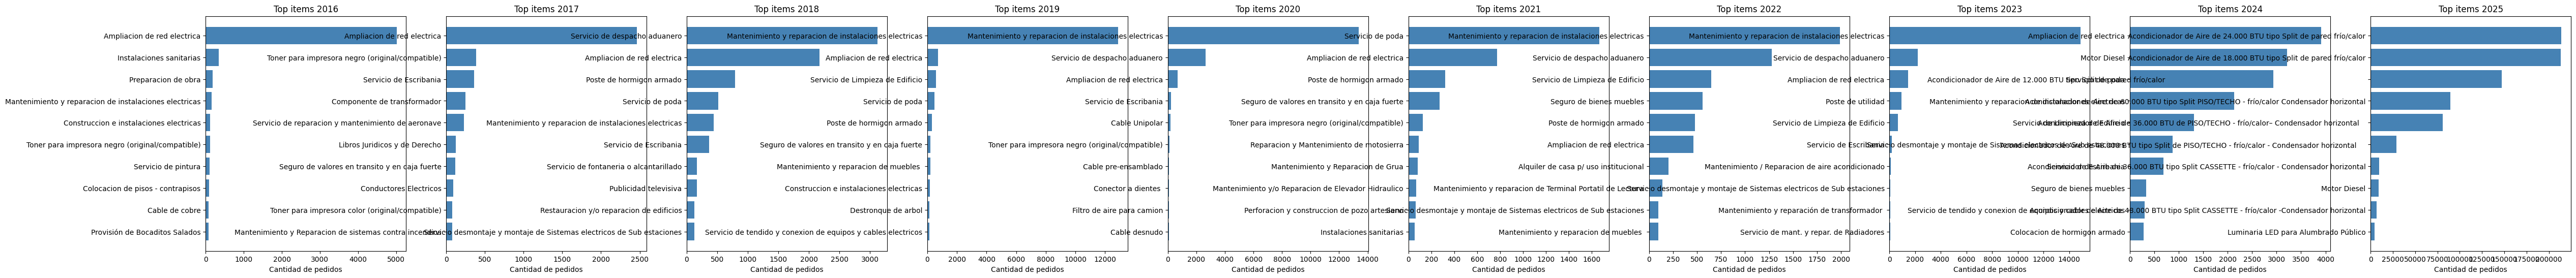

In [23]:
años = sorted(items_mas_pedidos["year_compiled"].unique())
fig, axes = plt.subplots(1, len(años), figsize=(6*len(años), 6), sharey=False)

if len(años) == 1:
    axes = [axes]

for ax, year in zip(axes, años):
    datos_año = items_mas_pedidos[items_mas_pedidos["year_compiled"] == year].head(10)
    ax.barh(datos_año["item"], datos_año["total_items"], color='steelblue')
    ax.set_title(f'Top items {year}')
    ax.set_xlabel('Cantidad de pedidos')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

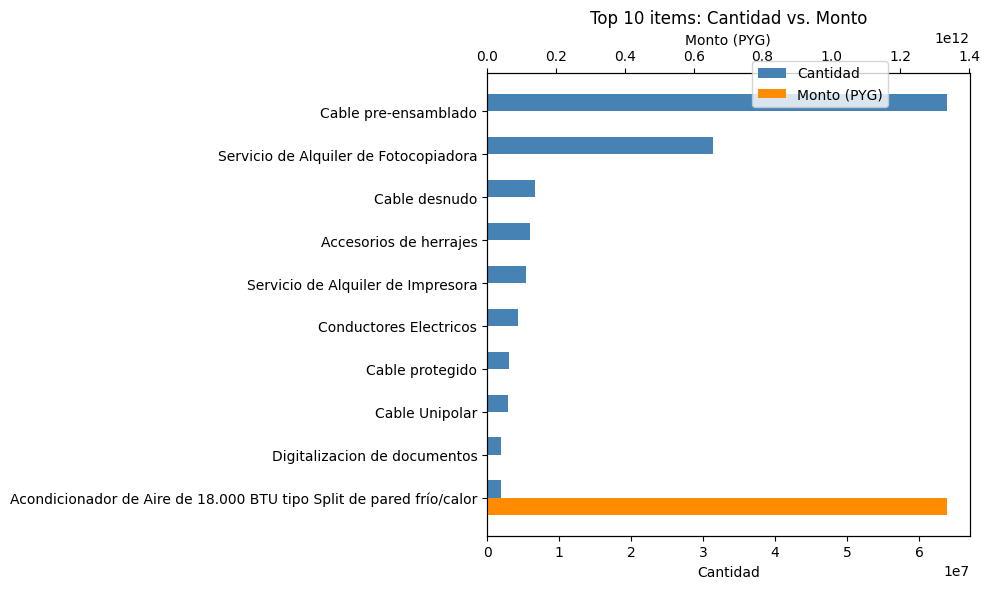

In [ ]:
import numpy as np

resumen = dataset_cleared.groupby('item').agg(cantidad=('quantity', 'sum'), monto=('amount', 'sum')).sort_values('cantidad', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(resumen))
width = 0.4

ax1.barh(x - width/2, resumen['cantidad'], height=width, color='steelblue', label='Cantidad')
ax1.set_yticks(x)
ax1.set_yticklabels(resumen.index)
ax1.invert_yaxis()
ax1.set_xlabel('Cantidad')

ax2 = ax1.twiny()
ax2.barh(x + width/2, resumen['monto'], height=width, color='darkorange', label='Monto (PYG)')
ax2.set_xlabel('Monto (PYG)')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('Top 10 items: Cantidad vs. Monto')
plt.tight_layout()
plt.show()

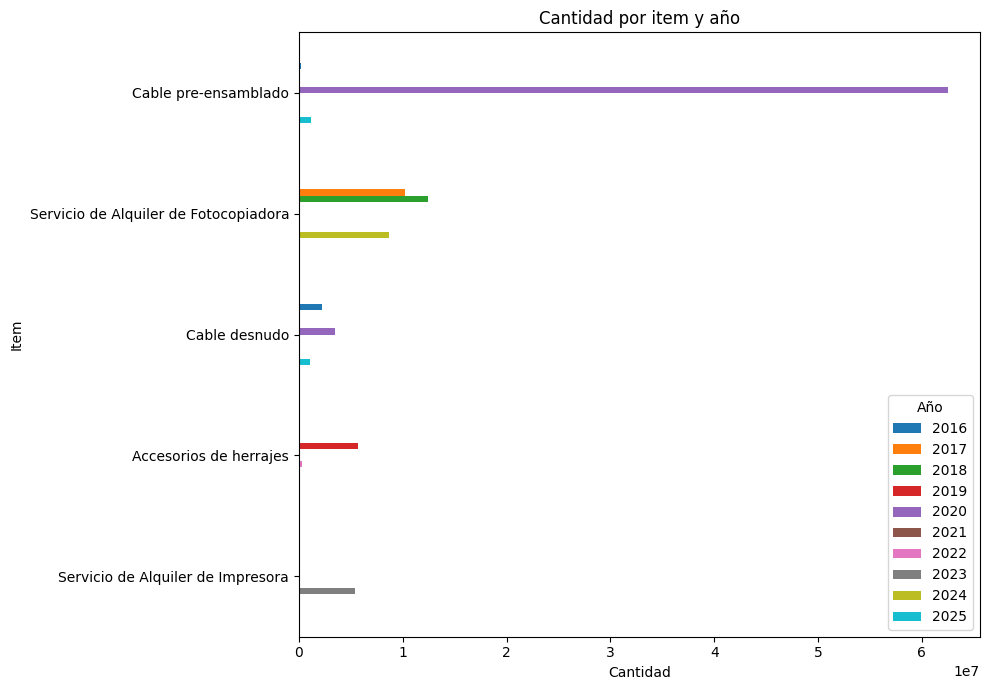

In [ ]:

# Pivotea: filas = item, columnas = year, valores = cantidad
tabla = dataset_cleared.pivot_table(index='item', columns='year_compiled', values='quantity', aggfunc='sum', fill_value=0)

# Tomamos los top 10 items según el total general
top_items = tabla.sum(axis=1).sort_values(ascending=False).head(5).index
tabla = tabla.loc[top_items]

tabla.plot(kind='barh', figsize=(10, 7))
plt.xlabel('Cantidad')
plt.ylabel('Item')
plt.title('Cantidad por item y año')
plt.legend(title='Año')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Es muy vago y requiere profundidad en un solo objeto

In [24]:
mask1 = dataset_cleared['item'].str.contains('Transformador de distribucion', case=False, na=False)
mask2 = ~dataset_cleared['item'].str.contains('Servicio', case=False, na=False)
#mask1 = dataset_cleared['item'].str.contains('Ampliacion de red electrica', case=False, na=False)
#mask1 = dataset_cleared['item'].str.contains('Servicio desmontaje y montaje de Sistemas electricos de Sub estaciones', case=False, na=False)

transformadores_ande = dataset_cleared[mask1 & mask2]
transformadores_ande.sample(10)

,date_awards,year_compiled,item,quantity,amount,currency
2222,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,376.0,10711444.0,PYG
2235,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,18.0,51000000.0,PYG
1611196,2025-09-26T00:00:00-04:00,2025,Transformador de distribucion trifasico,1500.0,20830557.0,PYG
69,2015-11-16T12:00:00-04:00,2018,Transformador de distribucion trifasico,16.0,36250000.0,PYG
1611195,2025-09-26T00:00:00-04:00,2025,Transformador de distribucion monofasico,600.0,8359363.0,PYG
19876,2016-07-25T12:00:00-04:00,2019,Transformador de distribucion trifasico,8.0,71566000.0,PYG
2223,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,18.0,36900000.0,PYG
21864,2024-10-16T00:00:00-04:00,2024,Transformador de distribucion monofasico,663.0,8670000.0,PYG
2218,2021-07-01T12:00:00-04:00,2024,Transformador de distribucion trifasico,18.0,51000000.0,PYG
3,2022-10-26T12:00:00-04:00,2025,Transformador de distribucion monofasico,1800.0,8627520.0,PYG


In [25]:
#ordenar
transformadores_ande = transformadores_ande.sort_values(by=["year_compiled", "item"])

print("Cantidad de registros de transformadores contratos de ANDE:", len(transformadores_ande))

Cantidad de registros de transformadores contratos de ANDE: 232


Tratar de obtener el grafico de todo lo obtenido

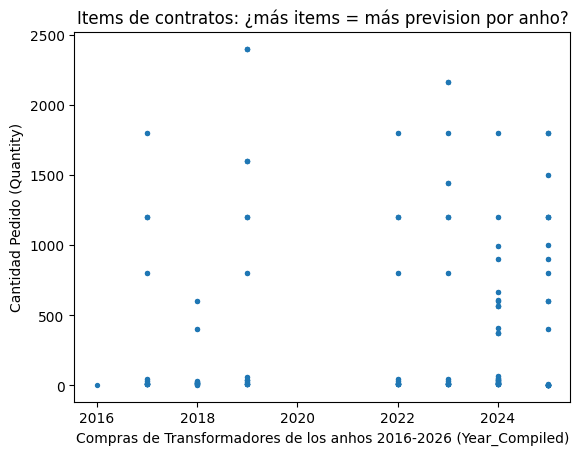

In [34]:
# Ejecutar esta celda (ya está completa): dibuja el primer gráfico del curso
plt.scatter(transformadores_ande["year_compiled"], transformadores_ande["quantity"], s=8)
plt.xlabel("Compras de Transformadores de los anhos 2016-2026 (Year_Compiled)")
plt.ylabel("Cantidad Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

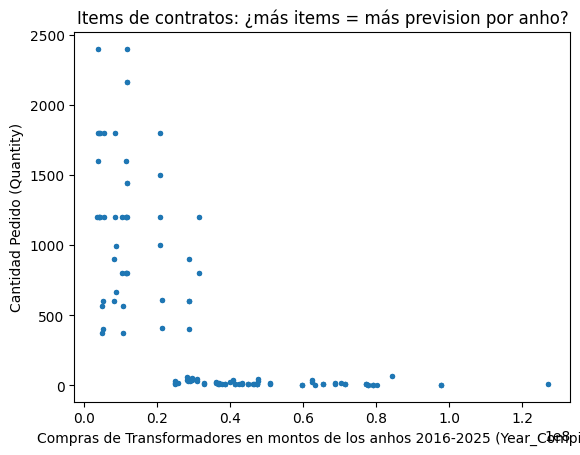

In [33]:
# Ejecutar esta celda (ya está completa): dibuja el primer gráfico del curso
import matplotlib.pyplot as plt

plt.scatter(transformadores_ande["amount"], transformadores_ande["quantity"], s=8)
plt.xlabel("Compras de Transformadores en montos de los anhos 2016-2025 (Year_Compiled)")
plt.ylabel("Cantidad Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

In [28]:
# Completar aquí
n_faltantes = transformadores_ande["quantity"].isna().sum()
print("Cantidad de registros faltantes en la columna 'quantity':", n_faltantes)

Cantidad de registros faltantes en la columna 'quantity': 0


In [29]:
transformadores_ande.head()

,date_awards,year_compiled,item,quantity,amount,currency
501,2017-03-02T12:00:00-04:00,2016,Transformador de distribucion monofasico,4.0,80153250.0,PYG
1453,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1200.0,3560000.0,PYG
1459,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1800.0,3800000.0,PYG
1465,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1200.0,3560000.0,PYG
1471,2018-07-05T12:00:00-04:00,2017,Transformador de distribucion monofasico,1800.0,3800000.0,PYG


Existen muchos valores con cantidades superiores a 3000

Con la informacion obtenida, retiramos los valores para visualizar el cambio

In [30]:
transformadores_ande = transformadores_ande[transformadores_ande["quantity"] <= 3000]
#transformadores_ande = transformadores_ande[transformadores_ande["quantity"] < 2]

transformadores_grouped = transformadores_ande.groupby(['item', 'year_compiled', 'currency'])['quantity'].sum().reset_index()
transformadores_grouped.head()

,item,year_compiled,currency,quantity
0,Transformador de distribucion monofasico,2016,PYG,4.0
1,Transformador de distribucion monofasico,2017,PYG,6000.0
2,Transformador de distribucion monofasico,2018,PYG,2000.0
3,Transformador de distribucion monofasico,2019,PYG,10400.0
4,Transformador de distribucion monofasico,2022,PYG,6000.0


Primer intento:
Generar un modelo de regresion para los datos reorganizados.

In [36]:
print("✓ Dataset: ", len(transformadores_grouped) ," filas cargadas.")
y = transformadores_grouped["quantity"]
X = transformadores_grouped[["year_compiled"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

datos_entrenamiento = len(X_train)
print("Datos de Entrenamiento = ", datos_entrenamiento)
print("✓ Modelo Terminado. R² =", round(modelo.score(X_test, y_test), 3))




✓ Dataset:  15  filas cargadas.
Datos de Entrenamiento =  10
✓ Modelo Terminado. R² = -0.952


Generamos una pequeña evaluación con datos de test para validar el proceso

In [37]:
# Predicciones con lo que haya
# Crear DataFrame con el mismo nombre de columna que X_train
#X_nuevo = pd.DataFrame({"year_compiled": [2026, 2027, 2028]})
y_pred = modelo.predict(X_test)


# evaluamos
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== MÉTRICAS DEL MODELO =====")
print(f"MAE  (Error Absoluto Medio): {mae:.3f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")
print(f"R²   (Coeficiente de Determinación): {r2:.3f}")

===== MÉTRICAS DEL MODELO =====
MAE  (Error Absoluto Medio): 4857.868
RMSE (Raíz del Error Cuadrático Medio): 5049.193
R²   (Coeficiente de Determinación): -0.952


Verificamos la gráfica para visibilizar el proceso

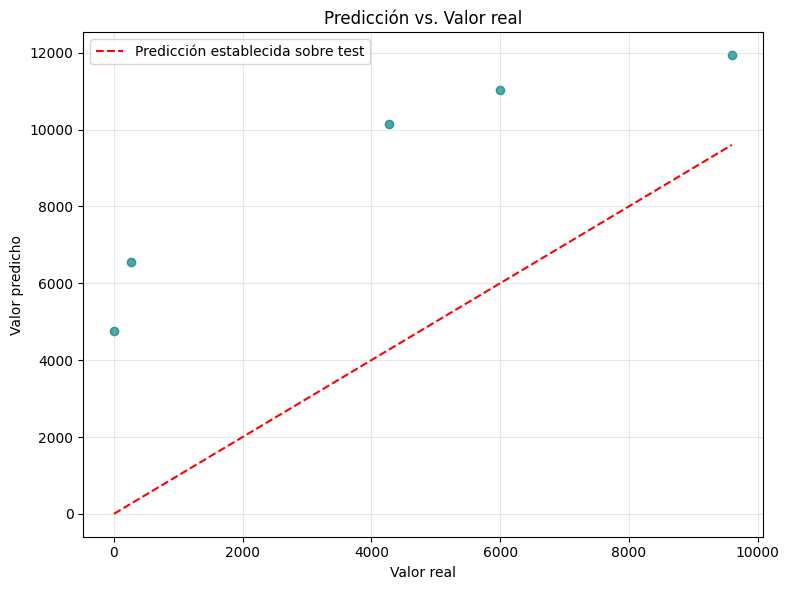

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, modelo.predict(X_test), color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción establecida sobre test')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Agregar una validacion pero considerando que tenemos pocos registros... puede ser bajo el rendimiento en especifico para el test

In [39]:
from sklearn.model_selection import cross_val_score

# Completar aquí
notas = cross_val_score(LinearRegression(), X, y, cv=5)
print(notas)

nota_honesta = round(notas.mean(), 2)

[-0.53737777 -2.84744855 -0.28875494 -0.11126657 -3.11261285]


De lo evaluado y con los datos, es muy posible que se tenga muy poco aprendizaje en base al resumen de los datos y las baja cantidad de ocurrencias.

## Segundo Round:
- Ya hemos probado validez con los datos, pero tomemos el ítem de mayor volumen de pedidos
- Arriesguemos tomando los datos de las fechas más largas en el detalle
- Incluso empleemos eso como dato para el año o sólo esa fecha para el modelo

In [40]:
mask1 = dataset_cleared['item'].str.contains('Cable', case=False, na=False)
mask2 = ~dataset_cleared['item'].str.contains('Servicio', case=False, na=False)
mask3 = ~dataset_cleared['item'].str.contains('Montaje', case=False, na=False)
mask4 = ~dataset_cleared['item'].str.contains('Terminación', case=False, na=False)

cables_ande = dataset_cleared[mask1 & mask2 & mask3 & mask4]
cables_ande.sample(10)

,date_awards,year_compiled,item,quantity,amount,currency
22950,2024-11-19T00:00:00-04:00,2024,Terminal para cable,1.0,3917.0,USD
23336,2021-09-28T12:00:00-04:00,2024,Cable desnudo,1.0,248500.0,USD
18515,2019-12-03T12:00:00-04:00,2020,Cable Unipolar,19200.0,58064.0,PYG
21811,2024-10-11T00:00:00-04:00,2024,Detector de cables y tubos subterráneos,1.0,92215479.0,PYG
18712,2019-12-03T12:00:00-04:00,2020,Cable pre-ensamblado,8400.0,13340.0,PYG
1766,2016-08-22T12:00:00-04:00,2018,Terminal a compres. para cable aluminio CU,1.0,21838.0,USD
1625,2018-06-14T12:00:00-04:00,2017,Preformado de tope para cable,1.0,17850.0,USD
5374,2017-12-04T16:24:10-04:00,2016,Cable desnudo,10000.0,27000.0,PYG
5414,2017-12-04T16:24:10-04:00,2016,Cable desnudo,30000.0,2850.0,PYG
836,2020-03-20T12:00:00-04:00,2020,Conector para cables multipares,900.0,8470.0,PYG


Como se visibiliza hay muchos datos de fecha con tiempo y no estructura normalizada que debería formatearse.

In [41]:
# Crear la nueva columna con formato datetime correcto
cables_ande['date_awards'] = pd.to_datetime(cables_ande['date_awards'])
# Convirtamos a un valor medible y diferenciado por año
cables_ande['year_frac'] = cables_ande['date_awards'].dt.year + (cables_ande['date_awards'].dt.dayofyear - 1) / 365
cables_ande_grouped = cables_ande.groupby(['item', 'year_frac', 'currency', 'date_awards'])['quantity'].sum().reset_index()
cables_ande_grouped.head()
cables_ande_grouped = cables_ande_grouped.sort_values(by=["year_frac", "item"])

print("Cantidad de registros de cables en contratos de ANDE:", len(cables_ande_grouped))

Cantidad de registros de cables en contratos de ANDE: 297


/tmp/ipykernel_656/847408076.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cables_ande['date_awards'] = pd.to_datetime(cables_ande['date_awards'])
/tmp/ipykernel_656/847408076.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cables_ande['year_frac'] = cables_ande['date_awards'].dt.year + (cables_ande['date_awards'].dt.dayofyear - 1) / 365


In [42]:
cables_ande_grouped.head()

,item,year_frac,currency,date_awards,quantity
125,Cable galvanizado de acero,2015.898630,USD,2015-11-25 12:00:00-04:00,3.0
135,Cable pre-ensamblado,2015.898630,USD,2015-11-25 12:00:00-04:00,3.0
166,Cable protegido,2015.898630,USD,2015-11-25 12:00:00-04:00,3.0
136,Cable pre-ensamblado,2016.134247,PYG,2016-02-19 12:00:00-04:00,6000.0
56,Cable de cobre,2016.243836,PYG,2016-03-30 12:00:00-04:00,32600.0


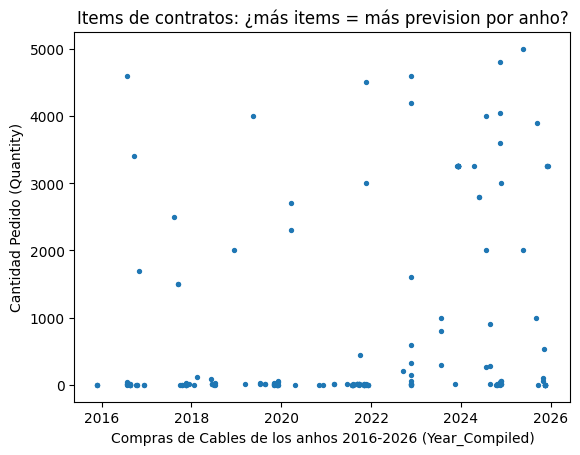

In [45]:
# Ejecutar esta celda (ya está completa): dibuja el primer gráfico del curso
import matplotlib.pyplot as plt

plt.scatter(cables_ande_grouped["year_frac"], cables_ande_grouped["quantity"], s=8)
plt.xlabel("Compras de Cables de los anhos 2016-2026 (Year_Compiled)")
plt.ylabel("Cantidad Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

In [44]:
cables_ande_grouped = cables_ande_grouped[cables_ande_grouped["quantity"] <= 5000]

Conformamos un siguiente modelo tomando la estructura de las fechas

In [48]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


print("✓ Dataset: ", len(cables_ande_grouped) ," filas cargadas.")
y = cables_ande_grouped["quantity"]
X = cables_ande_grouped[["year_frac"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

datos_entrenamiento = len(X_train)
print("Datos de Entrenamiento = ", datos_entrenamiento)
print("✓ Modelo Terminado. R² =", round(modelo.score(X_test, y_test), 3))

✓ Dataset:  177  filas cargadas.
Datos de Entrenamiento =  115
✓ Modelo Terminado. R² = 0.046


Visibilizamos la gráfica para ver el proceso

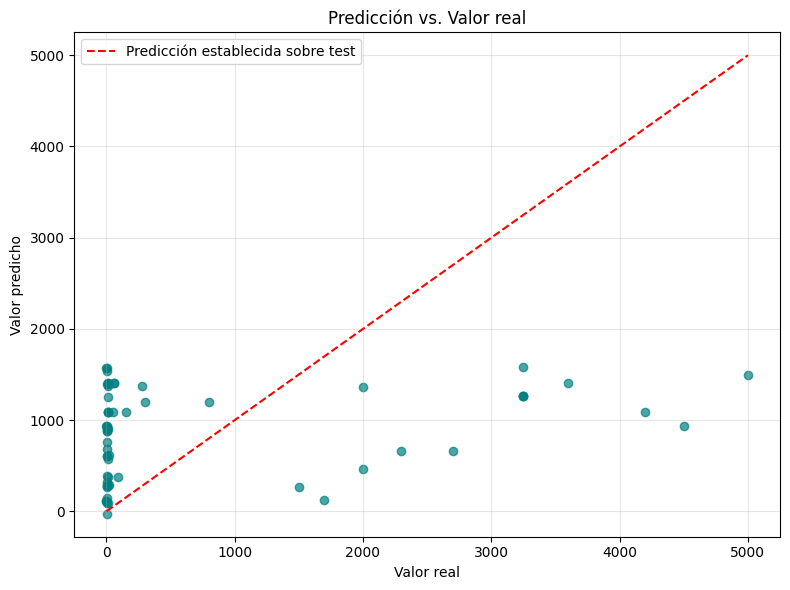

In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, modelo.predict(X_test), color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción establecida sobre test')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tercer Round:
- Ya hemos probado validez con los datos, pero cambiemos el enfoque a servicios
- Tomemos de vuelta los datos de las fechas más largas en el detalle

In [50]:
mask1 = dataset_cleared['item'].str.contains('Transformador', case=False, na=False)
mask2 = dataset_cleared['item'].str.contains('Servicio', case=False, na=False)
mask3 = dataset_cleared['item'].str.contains('Ampliacion de red electrica', case=False, na=False)
mask4 = dataset_cleared['item'].str.contains('Servicio desmontaje y montaje de Sistemas electricos de Sub estaciones', case=False, na=False)

serv_mant_ande = dataset_cleared[mask1 | mask2 | mask3 | mask4]
serv_mant_ande.sample(10)

,date_awards,year_compiled,item,quantity,amount,currency
3416,2017-12-28T12:00:00-04:00,2020,Servicio de despacho aduanero,1.0,7.500000e+05,PYG
4383,2018-10-30T12:00:00-04:00,2017,Ampliacion de red electrica,1.0,1.422000e+05,PYG
605,2017-12-07T12:00:00-04:00,2017,Servicio de Escribania,1.0,8.635520e+05,PYG
9465,2017-11-24T12:00:00-04:00,2016,Ampliacion de red electrica,1.0,2.673400e+04,PYG
3733,2018-07-31T12:00:00-04:00,2017,Ampliacion de red electrica,1.0,1.420104e+06,PYG
1619888,2023-06-14T12:00:00-04:00,2025,Servicio de poda,1.0,1.470829e+09,PYG
4085,2021-07-09T12:00:00-04:00,2024,Servicio de poda,1.0,1.032156e+09,PYG
5488,2021-03-12T12:00:00-04:00,2025,Servicio de poda,1.0,6.000000e+06,PYG
1619482,2023-06-14T12:00:00-04:00,2025,Servicio de poda,1.0,2.454598e+09,PYG
8598,2020-01-03T12:00:00-04:00,2025,Servicio desmontaje y montaje de Sistemas elec...,1.0,7.310000e+02,USD


In [51]:
print("Cantidad de registros relacionados con servicios en contratos de ANDE:", len(serv_mant_ande))

Cantidad de registros relacionados con servicios en contratos de ANDE: 56746


adf

In [61]:
# evaluemos el precio de Servicio de poda
mask1 = dataset_cleared['item'].str.contains('Poda', case=False, na=False)
mask2 = dataset_cleared['item'].str.contains('Servicio de Poda', case=False, na=False)

serv_poda_ande = dataset_cleared[mask1 | mask2]
print("Cantidad de registros relacionados con servicios en contratos de ANDE:", len(serv_poda_ande))

# misma estrategia anterior pero para servicios
serv_poda_ande['date_awards'] = pd.to_datetime(serv_poda_ande['date_awards'])
serv_poda_ande['year_frac'] = serv_poda_ande['date_awards'].dt.year + (serv_poda_ande['date_awards'].dt.dayofyear - 1) / 365
serv_poda_ande = serv_poda_ande.sort_values(by=["year_frac", "item"])
serv_poda_ande.sample(10)


Cantidad de registros relacionados con servicios en contratos de ANDE: 8648


/tmp/ipykernel_656/1100694134.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serv_poda_ande['date_awards'] = pd.to_datetime(serv_poda_ande['date_awards'])
/tmp/ipykernel_656/1100694134.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serv_poda_ande['year_frac'] = serv_poda_ande['date_awards'].dt.year + (serv_poda_ande['date_awards'].dt.dayofyear - 1) / 365


,date_awards,year_compiled,item,quantity,amount,currency,year_frac
1733,2018-01-10 12:00:00-04:00,2019,Servicio de poda,1.0,6.132513e+08,PYG,2018.024658
5993,2021-07-09 12:00:00-04:00,2024,Servicio de poda,1.0,0.000000e+00,PYG,2021.517808
2015,2016-09-05 12:00:00-04:00,2018,Servicio de poda,1.0,7.400315e+08,PYG,2016.679452
2240,2016-09-05 12:00:00-04:00,2018,Servicio de poda,1.0,5.685600e+08,PYG,2016.679452
1617941,2023-06-14 12:00:00-04:00,2025,Servicio de poda,1.0,2.302723e+09,PYG,2023.449315
1618808,2023-06-14 12:00:00-04:00,2025,Servicio de poda,1.0,3.228202e+09,PYG,2023.449315
5776,2021-03-12 12:00:00-04:00,2025,Servicio de poda,1.0,3.000000e+06,PYG,2021.191781
1619032,2023-06-14 12:00:00-04:00,2025,Servicio de poda,1.0,2.192015e+09,PYG,2023.449315
4565,2022-03-24 12:00:00-04:00,2024,Servicio de poda,1.0,1.195525e+09,PYG,2022.224658
5847,2021-07-09 12:00:00-04:00,2024,Servicio de poda,1.0,1.386183e+09,PYG,2021.517808


Se encuentra una mayor consistencia de datos y falta visualizar para estudiar su dispersión.

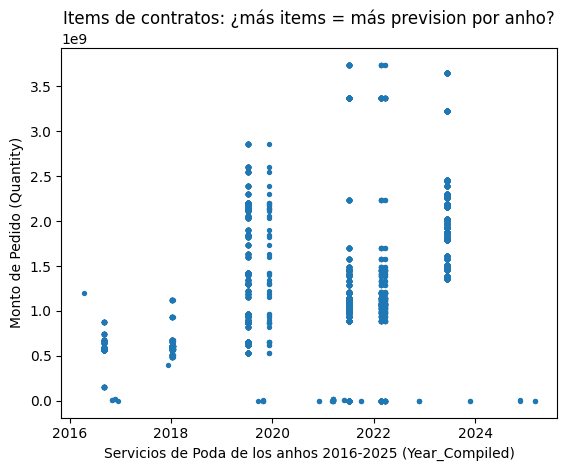

In [64]:
plt.scatter(serv_poda_ande["year_frac"], serv_poda_ande["amount"], s=8)
plt.xlabel("Servicios de Poda de los anhos 2016-2025 (Year_Compiled)")
plt.ylabel("Monto de Pedido (Quantity)")
plt.title("Items de contratos: ¿más items = más prevision por anho?")
plt.show()

Se pueden eliminar los valores superiores para visualizar el comportamiento en un entrenamiento

In [63]:
serv_poda_ande = serv_poda_ande[serv_poda_ande["amount"] <= 10000000000]

Luego ya sabemos el camino y realizamos el intento del modelo lineal

In [65]:
print("✓ Dataset: ", len(serv_poda_ande) ," filas cargadas.")
y = serv_poda_ande["amount"]
X = serv_poda_ande[["year_frac"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

datos_entrenamiento = len(X_train)
print("Datos de Entrenamiento = ", datos_entrenamiento)
print("✓ Modelo Terminado. R² =", round(modelo.score(X_test, y_test), 3))

✓ Dataset:  8616  filas cargadas.
Datos de Entrenamiento =  6892
✓ Modelo Terminado. R² = 0.248


Visualizamos el rendimiento en el gráfico para análisis los posibles datos que nos impiden un mejor fit.

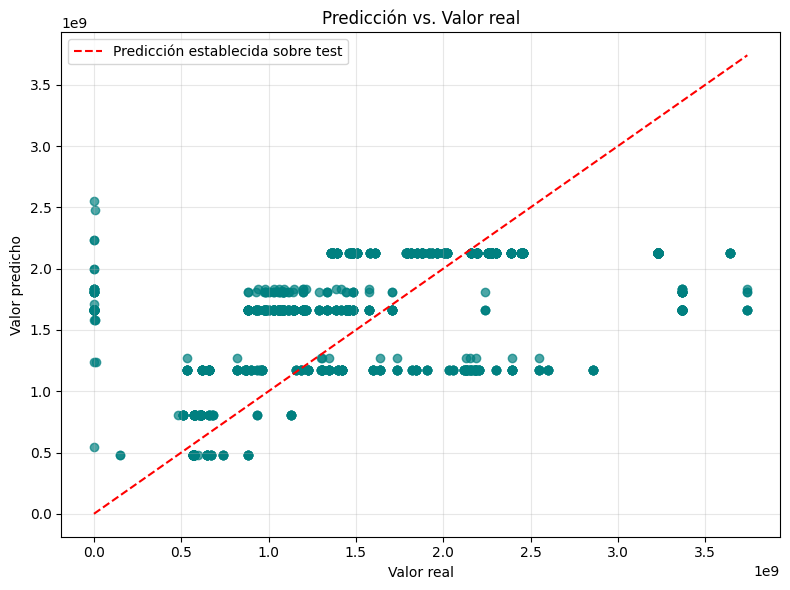

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, modelo.predict(X_test), color='teal', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Predicción establecida sobre test')
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Predicción vs. Valor real')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluamos su puntaje e intetamos usarlo para predecir

In [67]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicciones con lo que haya
#años_futuros = np.array([[2027], [2028]])
y_pred = modelo.predict(X_test)


# evaluamos
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== MÉTRICAS DEL MODELO =====")
print(f"MAE  (Error Absoluto Medio): {mae:.3f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")
print(f"R²   (Coeficiente de Determinación): {r2:.3f}")

===== MÉTRICAS DEL MODELO =====
MAE  (Error Absoluto Medio): 633612302.478
RMSE (Raíz del Error Cuadrático Medio): 822743684.892
R²   (Coeficiente de Determinación): 0.248


Le damos una nota para mejorar nuestras evaluaciones

In [68]:
from sklearn.model_selection import cross_val_score

# Completar aquí
notas = cross_val_score(LinearRegression(), X, y, cv=5)
print(notas)

nota_honesta = round(notas.mean(), 2)

[ 0.20810223 -0.13586237 -0.13824814  0.1070995  -0.20336838]


Merece una prueba al menos para guardar el modelo y emplear un Pipeline

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# ==== Crear pipeline ====
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

y = serv_poda_ande["amount"]
X = serv_poda_ande[["year_frac"]]

# ==== Entrenar ====
pipeline.fit(X, y)

# ==== Predicciones ====
y_pred = pipeline.predict(X)

# ==== Métricas ====
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("📊 Métricas del modelo:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² : {r2:.4f}")

# ==== Guardar modelo ====
joblib.dump(pipeline,DATA_DIR+"/modelo_regresion_servicio_poda.pkl")
print("✅ Modelo guardado en 'modelo_regresion_servicio_poda.pkl'")

📊 Métricas del modelo:
MAE: 646558532.6971
MSE: 687586325089071360.0000
R² : 0.2598
✅ Modelo guardado en 'modelo_regresion_servicio_poda.pkl'
